# Heart Disease Prediction using Machine Learning

## Atigala AVDSK (IT22589972)

### Task:
- Data Loading & Preprocessing
- Random Forest Model Implementation
- Model Evaluation

In [16]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [17]:
# Load dataset
df = pd.read_csv("../data/heart.csv")

# Display first 5 rows to understand data structure
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [18]:
# Convert categorical variables into numeric format
# This is required for machine learning models
df = pd.get_dummies(df, drop_first=True)

In [19]:
# Split dataset into features (X) and target variable (y)

# X = input features (all columns except target)
# y = output label (HeartDisease)

X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

In [20]:
# Split data into training and testing sets
# 80% training, 20% testing

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
# Create Random Forest model
# n_estimators = number of decision trees

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
)

# Train the model using training data
rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
# Make predictions on test data
y_pred_rf = rf_model.predict(X_test)

In [23]:
# Evaluate model accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("===== Random Forest Results =====")
print("Accuracy:", rf_accuracy)

===== Random Forest Results =====
Accuracy: 0.8695652173913043


In [24]:
# Confusion Matrix
# Shows correct and incorrect predictions

cm = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[65 12]
 [12 95]]


In [25]:
# Classification Report
# Includes precision, recall, f1-score

print("Classification Report:\n", classification_report(y_test, y_pred_rf))

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.84      0.84        77
           1       0.89      0.89      0.89       107

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184



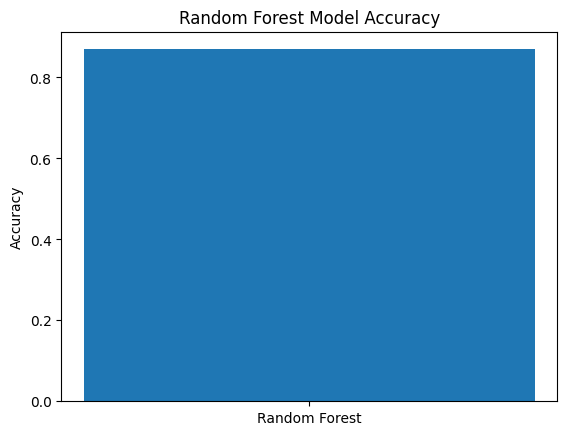

In [26]:
# Visualize model accuracy

plt.bar(["Random Forest"], [rf_accuracy])
plt.title("Random Forest Model Accuracy")
plt.ylabel("Accuracy")
plt.show()

## Model Improvement: Cross-Validation, Hyperparameter Tuning, and Threshold Optimization

This section upgrades the Random Forest pipeline with:
- Stratified cross-validation
- Hyperparameter tuning (RandomizedSearchCV)
- Medical-focused metrics (Precision, Recall, F1, ROC-AUC)
- Decision threshold analysis

In [27]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_validate
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Baseline CV scores for current Random Forest model
baseline_rf_cv = cross_validate(
    rf_model,
    X,
    y,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc",
    },
)

print("Baseline Random Forest (5-fold CV)")
for metric in ["test_accuracy", "test_precision", "test_recall", "test_f1", "test_roc_auc"]:
    print(f"{metric}: {baseline_rf_cv[metric].mean():.4f} (+/- {baseline_rf_cv[metric].std():.4f})")

Baseline Random Forest (5-fold CV)
test_accuracy: 0.8638 (+/- 0.0251)
test_precision: 0.8595 (+/- 0.0352)
test_recall: 0.9036 (+/- 0.0323)
test_f1: 0.8802 (+/- 0.0217)
test_roc_auc: 0.9273 (+/- 0.0226)


In [28]:
# Hyperparameter tuning for Random Forest
param_dist = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
    "class_weight": [None, "balanced"],
}

random_search_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=30,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    random_state=42,
)

random_search_rf.fit(X_train, y_train)
best_rf = random_search_rf.best_estimator_

print("Best RF Params:", random_search_rf.best_params_)
print("Best CV F1:", round(random_search_rf.best_score_, 4))

# Evaluate tuned model on test set
best_rf.fit(X_train, y_train)
y_pred_rf_tuned = best_rf.predict(X_test)
y_proba_rf_tuned = best_rf.predict_proba(X_test)[:, 1]

print("\nTuned Random Forest Test Metrics")
print("Accuracy :", round(accuracy_score(y_test, y_pred_rf_tuned), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf_tuned), 4))
print("Recall   :", round(recall_score(y_test, y_pred_rf_tuned), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_rf_tuned), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_proba_rf_tuned), 4))

Best RF Params: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None, 'class_weight': None}
Best CV F1: 0.8836

Tuned Random Forest Test Metrics
Accuracy : 0.8641
Precision: 0.8942
Recall   : 0.8692
F1 Score : 0.8815
ROC-AUC  : 0.9383


   threshold  precision    recall        f1
0       0.30   0.834711  0.943925  0.885965
1       0.35   0.863248  0.943925  0.901786
2       0.40   0.868421  0.925234  0.895928
3       0.45   0.879630  0.887850  0.883721
4       0.50   0.894231  0.869159  0.881517
5       0.55   0.902913  0.869159  0.885714
6       0.60   0.910891  0.859813  0.884615
7       0.65   0.935484  0.813084  0.870000
8       0.70   0.959459  0.663551  0.784530


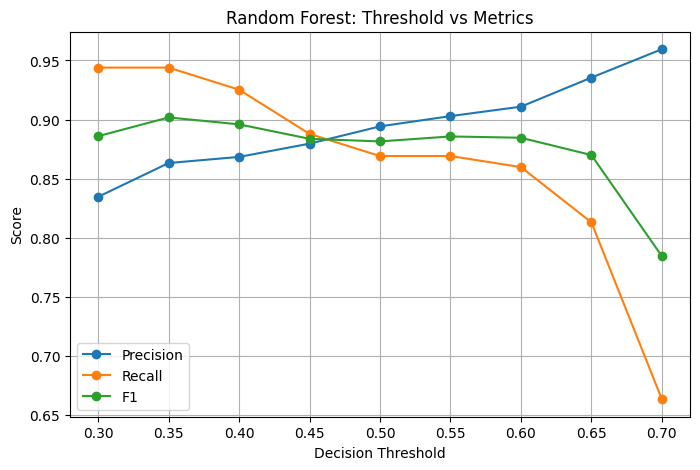

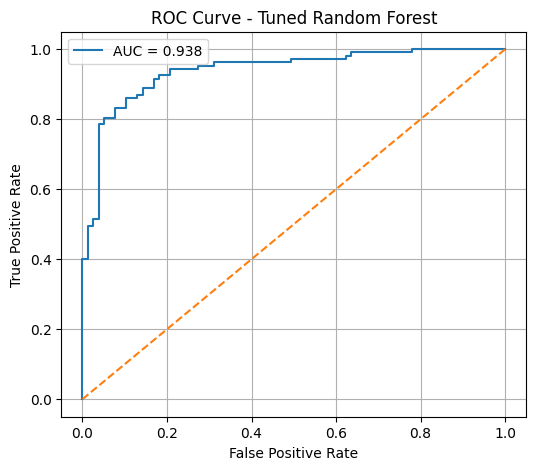

In [29]:
# Decision threshold optimization
thresholds = [i / 100 for i in range(30, 71, 5)]
rf_threshold_results = []

for t in thresholds:
    y_pred_thr = (y_proba_rf_tuned >= t).astype(int)
    rf_threshold_results.append(
        {
            "threshold": t,
            "precision": precision_score(y_test, y_pred_thr),
            "recall": recall_score(y_test, y_pred_thr),
            "f1": f1_score(y_test, y_pred_thr),
        }
    )

rf_threshold_df = pd.DataFrame(rf_threshold_results)
print(rf_threshold_df)

plt.figure(figsize=(8, 5))
plt.plot(rf_threshold_df["threshold"], rf_threshold_df["precision"], marker="o", label="Precision")
plt.plot(rf_threshold_df["threshold"], rf_threshold_df["recall"], marker="o", label="Recall")
plt.plot(rf_threshold_df["threshold"], rf_threshold_df["f1"], marker="o", label="F1")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Random Forest: Threshold vs Metrics")
plt.legend()
plt.grid(True)
plt.show()

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf_tuned)
plt.figure(figsize=(6, 5))
plt.plot(fpr_rf, tpr_rf, label=f"AUC = {roc_auc_score(y_test, y_proba_rf_tuned):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Random Forest")
plt.legend()
plt.grid(True)
plt.show()

In [31]:
# Save tuned Random Forest metrics for comparison notebook
import json

best_rf_row = rf_threshold_df.loc[rf_threshold_df["f1"].idxmax()]
best_rf_threshold = float(best_rf_row["threshold"])

y_pred_rf_best = (y_proba_rf_tuned >= best_rf_threshold).astype(int)

rf_metrics = {
    "model": "Random Forest",
    "threshold": round(best_rf_threshold, 4),
    "accuracy": round(float(accuracy_score(y_test, y_pred_rf_best)), 4),
    "precision": round(float(precision_score(y_test, y_pred_rf_best)), 4),
    "recall": round(float(recall_score(y_test, y_pred_rf_best)), 4),
    "f1": round(float(f1_score(y_test, y_pred_rf_best)), 4),
    "auc": round(float(roc_auc_score(y_test, y_proba_rf_tuned)), 4),
}

with open("../comparison/random_forest.json", "w") as f:
    json.dump(rf_metrics, f, indent=2)

print("Saved ../comparison/random_forest.json")
rf_metrics

Saved ../comparison/random_forest.json


{'model': 'Random Forest',
 'threshold': 0.35,
 'accuracy': 0.8804,
 'precision': 0.8632,
 'recall': 0.9439,
 'f1': 0.9018,
 'auc': 0.9383}